# Analyse du marché Airbnb à New York
**Objectif :** Explorer le jeu de données des locations Airbnb à New York (2019) pour identifier les tendances de prix selon les quartiers et les types de logements

In [1]:
import pandas as pd
import sqlite3

# 1. Chargement direct depuis l'URL
print("Téléchargement des données de New York en cours...")
url = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/AB_NYC_2019.csv'
df_nyc = pd.read_csv(url)

# 2. Nettoyage des données
colonnes_utiles = [
    'id', 'neighbourhood_group', 'neighbourhood', 'room_type',
    'price', 'minimum_nights', 'number_of_reviews'
]
df_clean = df_nyc[colonnes_utiles].copy()

# Les données brutes contiennent souvent des erreurs.
# Ici, nous supprimons les annonces dont le prix est de 0$ (des erreurs de saisie) et nous gérons les valeurs manquantes pour les commentaires.
df_clean = df_clean.dropna(subset=['price', 'neighbourhood'])
df_clean = df_clean[df_clean['price'] > 0]
df_clean['number_of_reviews'] = df_clean['number_of_reviews'].fillna(0)

print(f"Nettoyage terminé ! Il reste {len(df_clean)} annonces valides.")

# 3. Création de la base SQL
conn = sqlite3.connect('airbnb_nyc.db')
df_clean.to_sql('listings', conn, if_exists='replace', index=False)

# 4. Le Top 10 des quartiers les plus chers de Manhattan
requete_sql = """
SELECT
    neighbourhood AS Quartier,
    COUNT(*) AS Nombre_d_Annonces,
    ROUND(AVG(price), 2) AS Prix_Moyen_USD
FROM
    listings
WHERE
    neighbourhood_group = 'Manhattan'
GROUP BY
    neighbourhood
HAVING
    COUNT(*) > 50
ORDER BY
    Prix_Moyen_USD DESC
LIMIT 10;
"""

df_top_quartiers = pd.read_sql_query(requete_sql, conn)

# 5. Affichage du résultat final
print("\n--- TOP 10 DES QUARTIERS LES PLUS CHERS à MANHATTAN ---")
display(df_top_quartiers)

Téléchargement des données de New York en cours...
Nettoyage terminé ! Il reste 48884 annonces valides.

--- TOP 10 DES QUARTIERS LES PLUS CHERS à MANHATTAN ---


,Quartier,Nombre_d_Annonces,Prix_Moyen_USD
0,Tribeca,177,490.64
1,Battery Park City,70,367.56
2,Flatiron District,80,341.93
3,NoHo,78,295.72
4,SoHo,358,287.10
5,Midtown,1545,282.72
6,West Village,768,267.68
7,Greenwich Village,392,263.41
8,Chelsea,1113,249.74
9,Theater District,288,248.01


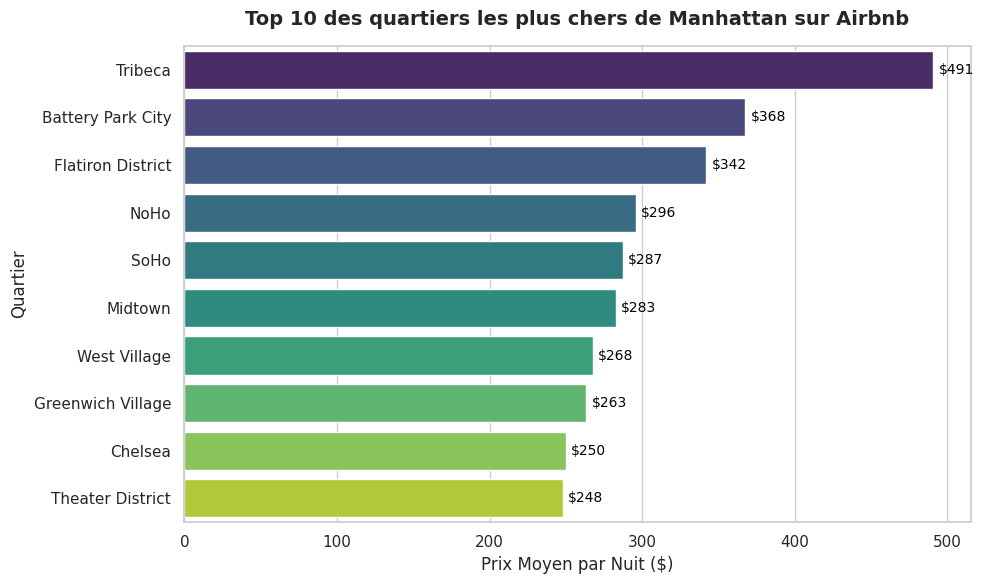

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuration de la taille et du style du graphique
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 2. Création du diagramme en barres
ax = sns.barplot(
    x="Prix_Moyen_USD",
    y="Quartier",
    data=df_top_quartiers,
    palette="viridis",
    hue="Quartier",
    legend=False
)

# 3. Ajout des titres et des étiquettes d'axes
plt.title("Top 10 des quartiers les plus chers de Manhattan sur Airbnb", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Prix Moyen par Nuit ($)", fontsize=12)
plt.ylabel("Quartier", fontsize=12)

# 4. Ajout des montants directement sur les barres
for p in ax.patches:
    ax.annotate(f"${p.get_width():.0f}",
                (p.get_width() + 15, p.get_y() + p.get_height() / 2.),
                ha='center', va='center', fontsize=10, color='black')

# 5. Ajustement des marges et affichage
plt.tight_layout()
plt.show()

###  Conclusion sur les quartiers :
L'analyse SQL et le graphique ci-dessus révèlent que **Tribeca** est le quartier le plus exclusif de Manhattan, avec un prix moyen frôlant les 500$ la nuit. Cela peut s'expliquer par la forte concentration de lofts luxueux dans cette zone historique.

In [3]:

# catégories de prix
requete_categories = """
SELECT
    room_type AS Type_de_Logement,
    CASE
        WHEN price < 100 THEN '1- Budget (< 100$)'
        WHEN price BETWEEN 100 AND 250 THEN '2- Standard (100$ - 250$)'
        ELSE '3- Luxe (> 250$)'
    END AS Categorie_Prix,
    COUNT(*) AS Nombre_d_Annonces,
    ROUND(AVG(price), 2) AS Prix_Moyen_USD
FROM
    listings
GROUP BY
    Type_de_Logement,
    Categorie_Prix
ORDER BY
    Type_de_Logement,
    Categorie_Prix;
"""

df_categories = pd.read_sql_query(requete_categories, conn)

print("\n--- RÉPARTITION DES ANNONCES PAR TYPE ET CATÉGORIE DE PRIX ---")
display(df_categories)


--- RÉPARTITION DES ANNONCES PAR TYPE ET CATÉGORIE DE PRIX ---


,Type_de_Logement,Categorie_Prix,Nombre_d_Annonces,Prix_Moyen_USD
0,Entire home/apt,1- Budget (< 100$),3611,80.97
1,Entire home/apt,2- Standard (100$ - 250$),17098,164.17
2,Entire home/apt,3- Luxe (> 250$),4698,485.77
3,Private room,1- Budget (< 100$),17251,62.53
4,Private room,2- Standard (100$ - 250$),4588,134.10
5,Private room,3- Luxe (> 250$),480,646.89
6,Shared room,1- Budget (< 100$),1004,47.27
7,Shared room,2- Standard (100$ - 250$),124,142.25
8,Shared room,3- Luxe (> 250$),30,541.67


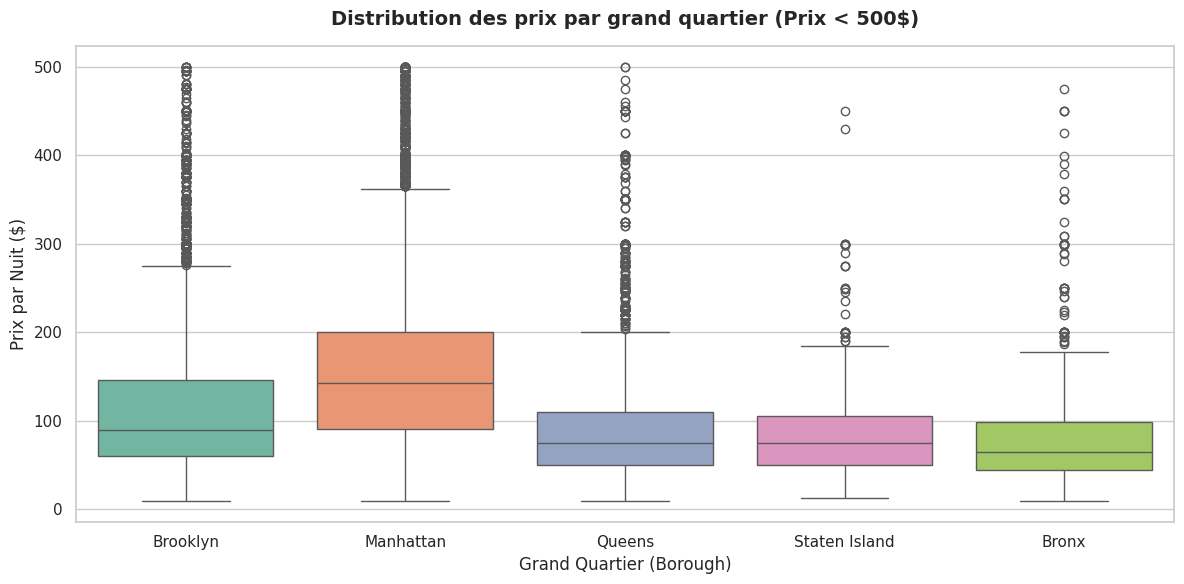

In [4]:
# DISTRIBUTION DES PRIX

plt.figure(figsize=(12, 6))

# Pour que le graphique soit lisible, on filtre les prix extrêmes (> 500$)
df_filtre = df_clean[df_clean['price'] < 500]

# Création du boxplot
sns.boxplot(
    x='neighbourhood_group',
    y='price',
    data=df_filtre,
    palette='Set2',
    hue='neighbourhood_group',
    legend=False
)

plt.title("Distribution des prix par grand quartier (Prix < 500$)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Grand Quartier (Borough)", fontsize=12)
plt.ylabel("Prix par Nuit ($)", fontsize=12)

plt.tight_layout()
plt.show()